# Validação visual — SCRFD 2.5G KPS (buffalo_m)

Notebook de validação do módulo `models/face_detector.py`.

- Carrega 5+ imagens do CelebA-HQ local
- Plota bbox + 5 landmarks rotulados
- Salva figuras em `notebooks/outputs/detector_validation/`

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CELEBAHQ_DIR = Path("/mnt/study-data/dcarvalho/datasets/celebahq")
OUTPUT_DIR = ROOT / "notebooks" / "outputs" / "detector_validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Project root: /home/dcarvalho/Lightweight-Face-De-identification
Output dir: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from insightface.data import get_image as ins_get_image

from models.face_detector import (
    LANDMARK_NAMES,
    FaceDetector,
    detect_face,
    _to_bgr_uint8,
)

detector = FaceDetector(ctx_id=-1)

COLORS = {
    "LE": "#e41a1c",
    "RE": "#377eb8",
    "N": "#4daf4a",
    "LM": "#984ea3",
    "RM": "#ff7f00",
}


def plot_detection(bgr: np.ndarray, detection, title: str, save_path: Path | None = None):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(rgb)

    x1, y1, x2, y2 = detection.bbox
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2)
    ax.add_patch(rect)

    for i, (x, y) in enumerate(detection.landmarks):
        name = LANDMARK_NAMES[i]
        ax.scatter(x, y, c=COLORS[name], s=60, zorder=3)
        ax.text(x + 4, y - 4, name, color=COLORS[name], fontsize=10, weight="bold")

    ax.set_title(f"{title} | score={detection.score:.3f}")
    ax.axis("off")
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)

/home/dcarvalho/Lightweight-Face-De-identification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dcarvalho/Lightweight-Face-De-identification/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/dcarvalho/.insightface/models/buffalo_m/det_2.5g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/w600k_r50.onnx recognition
set det-size: [(128, 128), (640, 640)]


Saved: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation/img_00000_landmarks.jpg


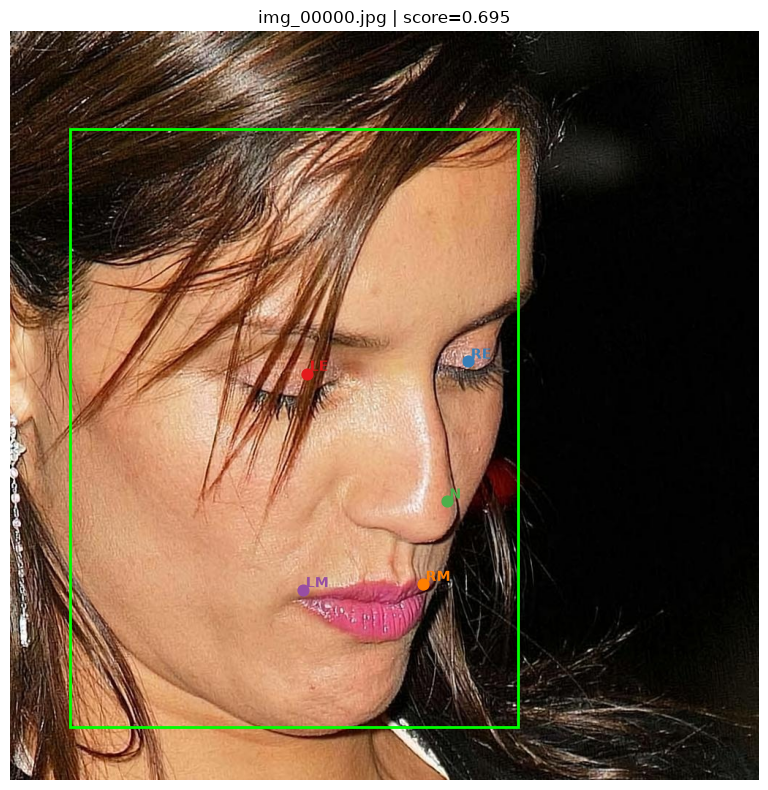

Saved: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation/img_00001_landmarks.jpg


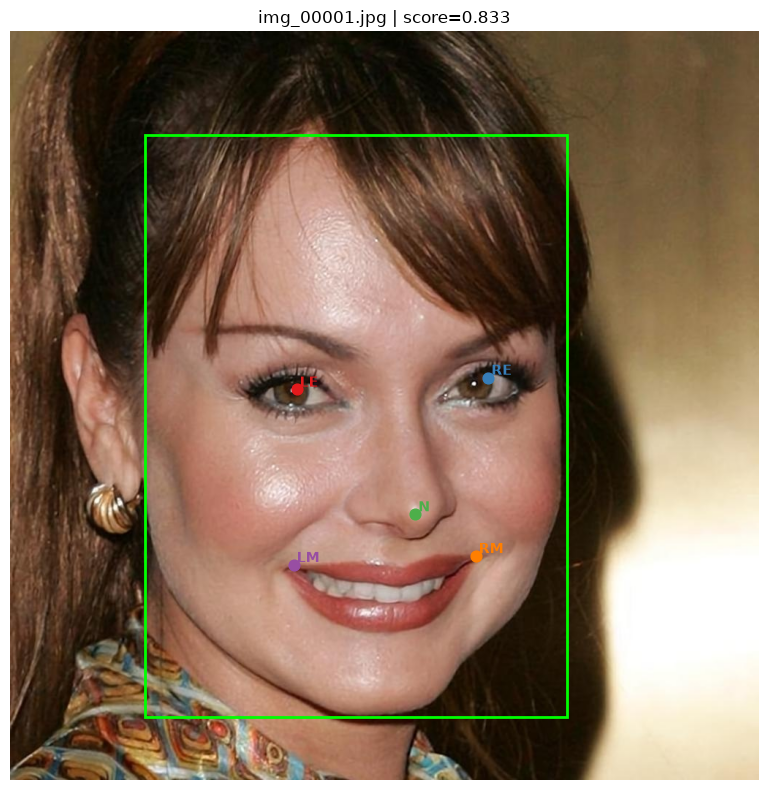

Saved: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation/img_00002_landmarks.jpg


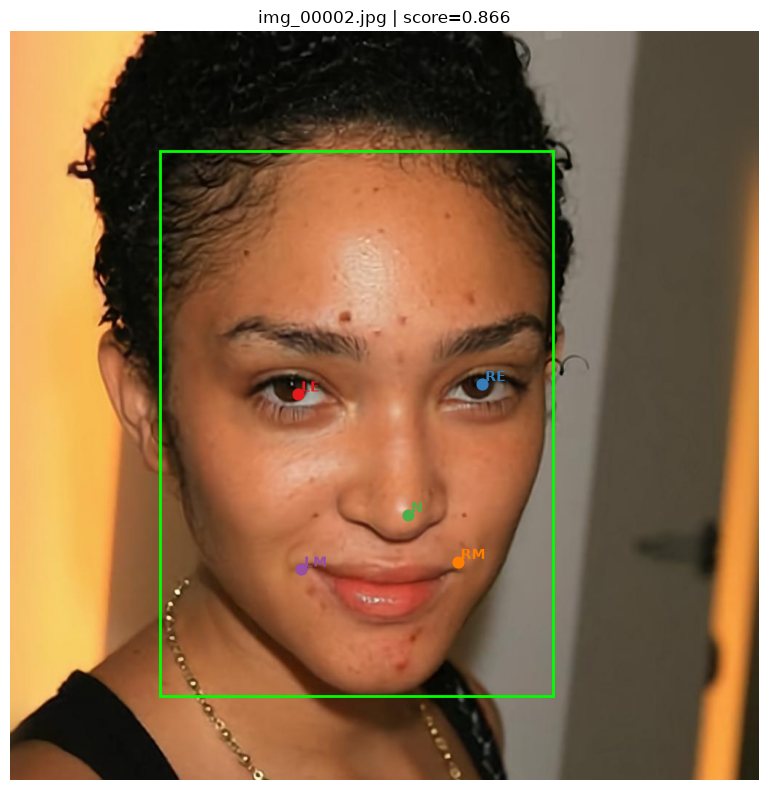

Saved: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation/img_00003_landmarks.jpg


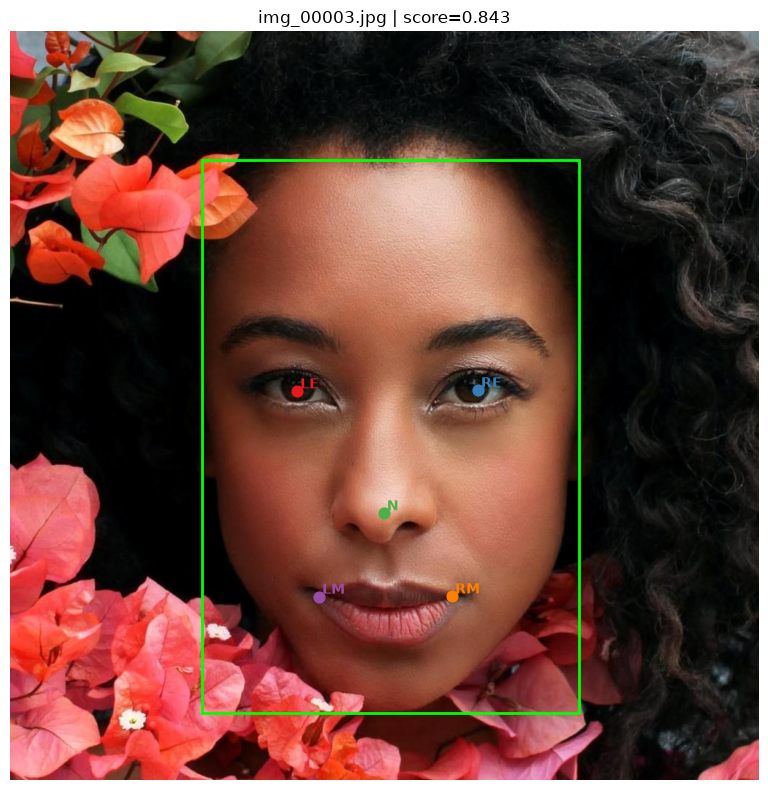

Saved: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation/img_00004_landmarks.jpg


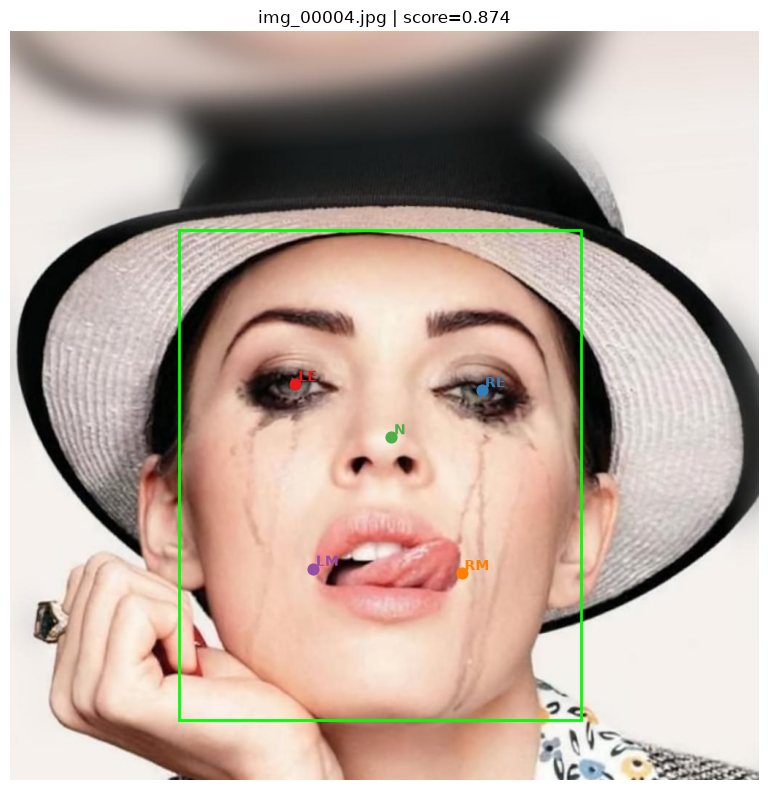

Saved: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation/img_00005_landmarks.jpg


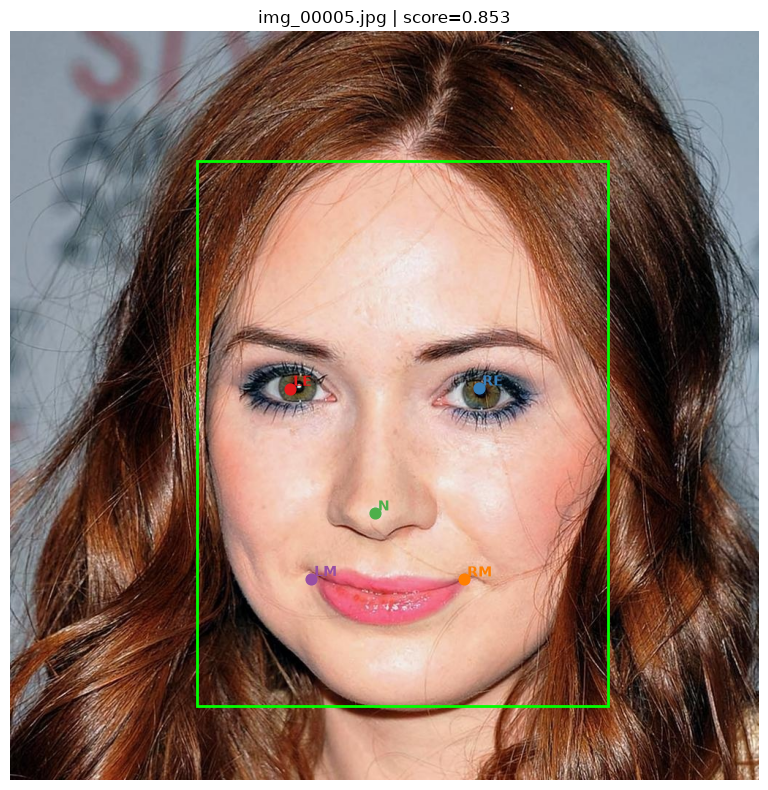

Saved: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation/img_00006_landmarks.jpg


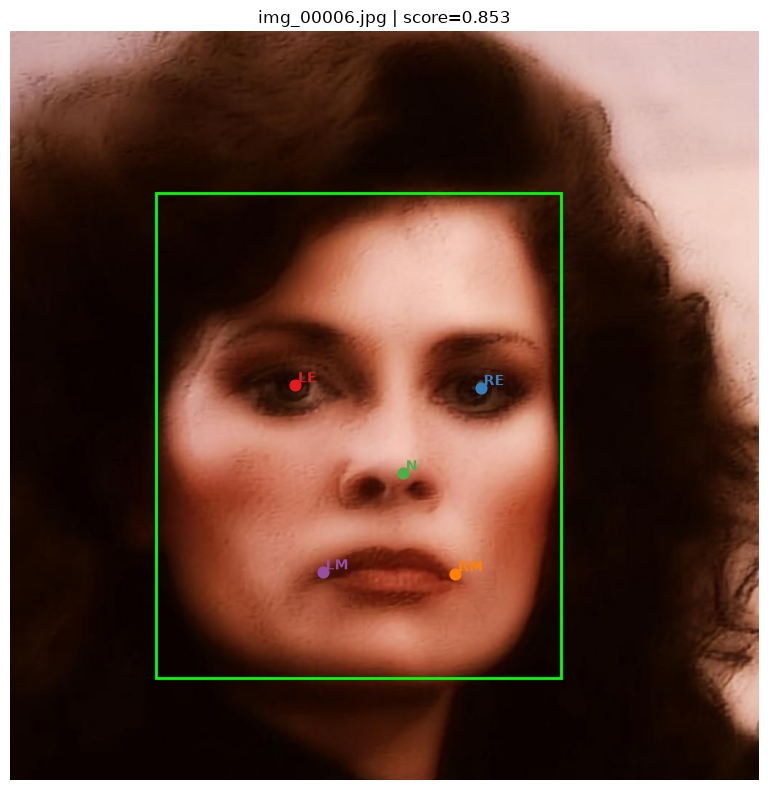

Saved: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation/img_00007_landmarks.jpg


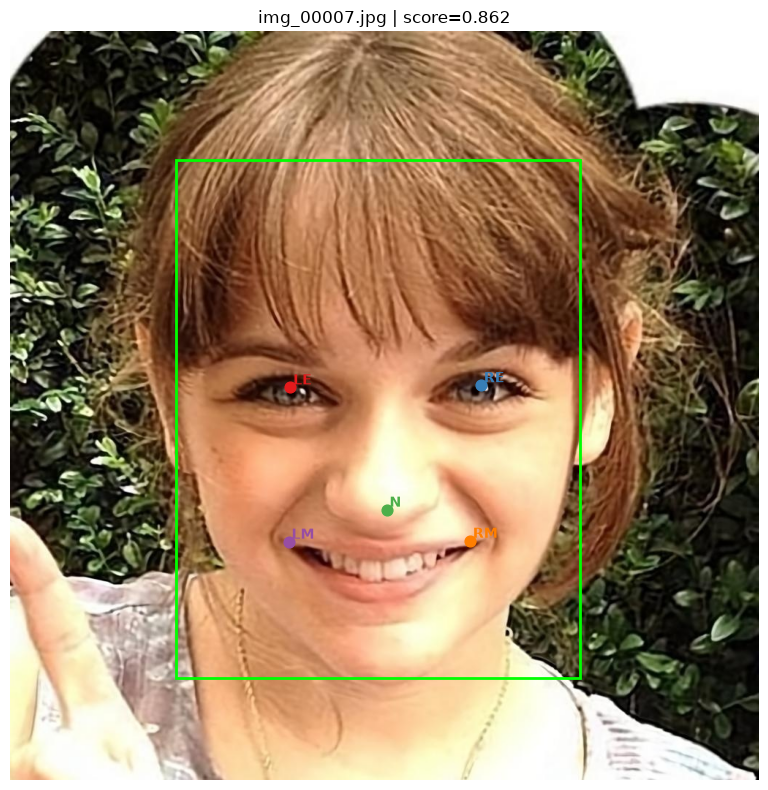


CelebA-HQ: 8/8 imagens com detecção


In [3]:
celebahq_images = sorted(CELEBAHQ_DIR.glob("img_*.jpg"))[:8]
if len(celebahq_images) < 5:
    raise RuntimeError(f"Esperadas 5+ imagens em {CELEBAHQ_DIR}")

results = []
for img_path in celebahq_images:
    bgr = _to_bgr_uint8(img_path)
    detection = detector.detect_best(img_path)
    status = "ok" if detection is not None else "no_face"
    results.append((img_path.name, status, detection))
    if detection is not None:
        plot_detection(
            bgr,
            detection,
            title=img_path.name,
            save_path=OUTPUT_DIR / f"{img_path.stem}_landmarks.jpg",
        )
    else:
        print(f"Sem face detectada: {img_path.name}")

n_ok = sum(1 for _, s, _ in results if s == "ok")
print(f"\nCelebA-HQ: {n_ok}/{len(results)} imagens com detecção")

Saved: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation/t1_landmarks.jpg


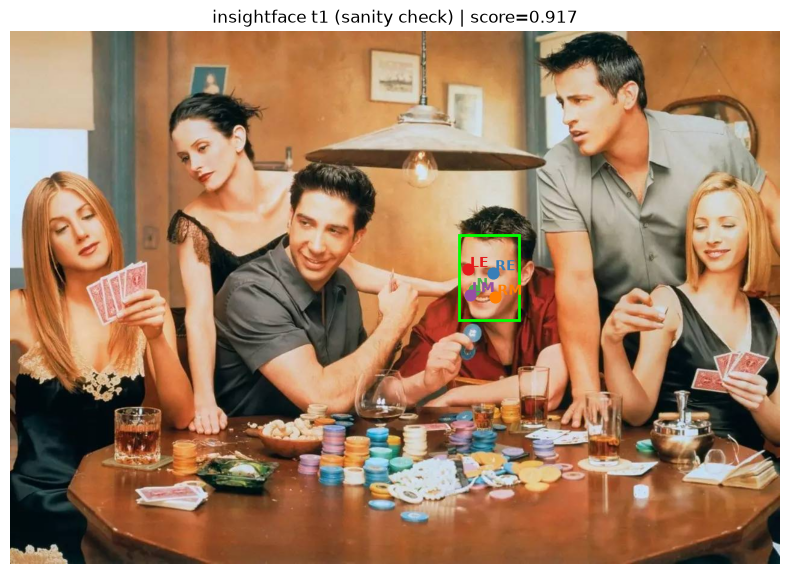

In [4]:
# Sanity check com imagem bundled do insightface
t1_bgr = ins_get_image("t1")
t1_detection = detector.detect_best(t1_bgr)

if t1_detection is not None:
    # Comparação rápida com draw_on do insightface
    faces = detector.app.get(t1_bgr)
    insightface_viz = detector.app.draw_on(t1_bgr, faces)
    cv2.imwrite(str(OUTPUT_DIR / "t1_insightface_draw_on.jpg"), insightface_viz)

    plot_detection(
        t1_bgr,
        t1_detection,
        title="insightface t1 (sanity check)",
        save_path=OUTPUT_DIR / "t1_landmarks.jpg",
    )
else:
    print("Falha no sanity check t1.jpg")

In [5]:
# Resumo
print("=== Resumo da validação ===")
for name, status, det in results:
    if det is not None:
        print(f"  {name}: score={det.score:.3f}")
    else:
        print(f"  {name}: SEM DETECÇÃO")
if t1_detection is not None:
    print(f"  t1.jpg (sanity): score={t1_detection.score:.3f}")
print(f"\nFiguras salvas em: {OUTPUT_DIR}")

=== Resumo da validação ===
  img_00000.jpg: score=0.695
  img_00001.jpg: score=0.833
  img_00002.jpg: score=0.866
  img_00003.jpg: score=0.843
  img_00004.jpg: score=0.874
  img_00005.jpg: score=0.853
  img_00006.jpg: score=0.853
  img_00007.jpg: score=0.862
  t1.jpg (sanity): score=0.917

Figuras salvas em: /home/dcarvalho/Lightweight-Face-De-identification/notebooks/outputs/detector_validation
